In [2]:
import os
# Change to the directory where the script is located to be able to import local modules
os.chdir("..")

In [8]:
from pathlib import Path
cwd = Path.cwd()
print(cwd)

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM


# Libraries 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Check the Index Dataframe 

In [9]:
df_index = pd.read_parquet(cwd/"data"/"index"/"runs.parquet")
print(df_index.shape)
df_index.head(-5)

(48, 13)


,dgp,run_id,path,created_at,git_commit,params,split_file,n,T,p,a,seed,split_seed
0,blackwell_yamauchi,cbbb93c7,data\raw\blackwell_yamauchi\cbbb93c7,2025-09-22T22:56:22Z,d456ea5,"{'T': 40, 'a': 1, 'beta': [-0.5, -0.5], 'dgp':...",data\splits\blackwell_yamauchi\N200_T40_p2_spl...,200,40,2,1,1,42
1,blackwell_yamauchi,c27fe204,data\raw\blackwell_yamauchi\c27fe204,2025-09-22T22:56:25Z,d456ea5,"{'T': 20, 'a': 1, 'beta': [-0.5, -0.5], 'dgp':...",data\splits\blackwell_yamauchi\N200_T20_p2_spl...,200,20,2,1,1,42
2,blackwell_yamauchi,4de2f3f4,data\raw\blackwell_yamauchi\4de2f3f4,2025-09-22T22:56:28Z,d456ea5,"{'T': 4, 'a': 1, 'beta': [-0.5, -0.5], 'dgp': ...",data\splits\blackwell_yamauchi\N200_T4_p2_spli...,200,4,2,1,1,42
3,blackwell_yamauchi,d9e512c6,data\raw\blackwell_yamauchi\d9e512c6,2025-09-22T22:56:31Z,d456ea5,"{'T': 40, 'a': 1, 'beta': [-0.5, -0.5, 1.0, -0...",data\splits\blackwell_yamauchi\N200_T40_p4_spl...,200,40,4,1,1,42
4,blackwell_yamauchi,3326a253,data\raw\blackwell_yamauchi\3326a253,2025-09-22T22:56:34Z,d456ea5,"{'T': 20, 'a': 1, 'beta': [-0.5, -0.5, 1.0, -0...",data\splits\blackwell_yamauchi\N200_T20_p4_spl...,200,20,4,1,1,42
5,blackwell_yamauchi,a85fc460,data\raw\blackwell_yamauchi\a85fc460,2025-09-22T22:56:37Z,d456ea5,"{'T': 4, 'a': 1, 'beta': [-0.5, -0.5, 1.0, -0....",data\splits\blackwell_yamauchi\N200_T4_p4_spli...,200,4,4,1,1,42
6,blackwell_yamauchi,a47217c2,data\raw\blackwell_yamauchi\a47217c2,2025-09-22T22:56:40Z,d456ea5,"{'T': 40, 'a': 2, 'beta': [-0.5, -0.5], 'dgp':...",data\splits\blackwell_yamauchi\N200_T40_p2_spl...,200,40,2,2,1,42
7,blackwell_yamauchi,2a2b0a99,data\raw\blackwell_yamauchi\2a2b0a99,2025-09-22T22:56:43Z,d456ea5,"{'T': 20, 'a': 2, 'beta': [-0.5, -0.5], 'dgp':...",data\splits\blackwell_yamauchi\N200_T20_p2_spl...,200,20,2,2,1,42
8,blackwell_yamauchi,dadff289,data\raw\blackwell_yamauchi\dadff289,2025-09-22T22:56:46Z,d456ea5,"{'T': 4, 'a': 2, 'beta': [-0.5, -0.5], 'dgp': ...",data\splits\blackwell_yamauchi\N200_T4_p2_spli...,200,4,2,2,1,42
9,blackwell_yamauchi,43813f6a,data\raw\blackwell_yamauchi\43813f6a,2025-09-22T22:56:49Z,d456ea5,"{'T': 40, 'a': 2, 'beta': [-0.5, -0.5, 1.0, -0...",data\splits\blackwell_yamauchi\N200_T40_p4_spl...,200,40,4,2,1,42


In [10]:
from utils.runs import load_by_params
from itertools import product 

dgp = "blackwell_yamauchi"

rho = [5,10,50] # n/T
params_grid = {
    "n": [200, 500, 1000, 3000],
    "seed": [1], 
    "a": [1,2], 
    "p": [2,4], 
}

T =  {n:[int(n/r) for r in rho] for n in params_grid["n"]}

beta_dict = {2:  [-0.5, -0.5], 4: [-0.5, -0.5, 1.0, -0.5]}
gamma_dict = {2: [1.0, 0.5], 4: [1.0, 0.5, 1.0, 1.0]}

params = {
    "phi": 0.3,
    "tau_F": 1.0, 
    "tau_C": 0.3,
    "mean_x": -0.5, 
    "offdiag": 0.2,
    "sigma_eps": 1.0, 
    "max_lag_x": 0, 
    "max_lag_d": 3,
    "split_seed": 42
    }

treatment_model = "logit"

params["treatment_model"] = treatment_model

df_manigest = []

for n, seed, a, p in product(*params_grid.values()):
  
    for t in T[n]:
        cfg = {"dgp": dgp,"n": n, "T": t, "seed": seed, "a": a, "p": p,
               "beta": beta_dict[p], "gamma": gamma_dict[p], **params}
        
        df, manifest = load_by_params(".", cfg)
        df_manigest.append((df,manifest))

In [15]:
filtered = [(df,manifest) for df,manifest in df_manigest if manifest["params"]["a"]== 2 ]

In [22]:
df,manifest = filtered[3]
for key in ["n","T","p","a"]:
    print(f"{key}: {manifest["params"][key]}")


n: 200
T: 40
p: 4
a: 2


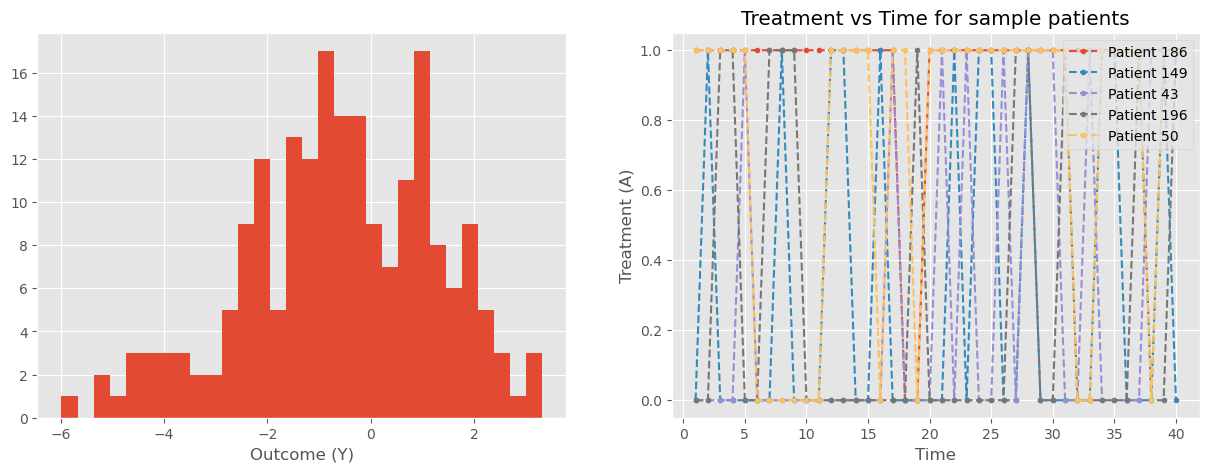

In [23]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

num = 5
seed = 42
sample_ids = df["patient_id"].drop_duplicates().sample(num)
#sample_ids = [train_ids[1881]]
fig,ax = plt.subplots(1,2,figsize = (15,5))
for pid in sample_ids:
    sub = df[df.patient_id == pid]
    #ax[0].plot(sub["t"], sub["Y"], "--.",label = f"Patient {pid}")
    ax[1].plot(sub["t"], sub["D"], "--.",label = f"Patient {pid}")

#ax[0].set_xlabel("Time")
#ax[0].set_ylabel("Outcome (Y)")
#ax[0].set_title("Outcome vs Time for sample patients")
#ax[0].legend()

ax[0].hist(df.Y,bins=30)
ax[0].set_xlabel("Outcome (Y)")
#ax[0].set_title("Outcome vs Time for sample patients")
#ax[0].legend()

ax[1].set_xlabel("Time")
ax[1].set_ylabel("Treatment (A)")
ax[1].set_title("Treatment vs Time for sample patients")
ax[1].legend(loc = "upper right")
plt.show()

In [24]:
import plotly.express as px

fig = px.histogram(
    df, 
    x="D", 
    animation_frame="t",   # animate over time
    nbins=20, 
    title="Distribution of D over time", 
    histnorm="probability",
    width=800,   # width in pixels
    height=600   # height in pixels
)
fig.update_layout(yaxis=dict(autorange=True))
fig.show()
